In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

PREDICTIONS_FILE = "../logs/classification/snapshot_predictions.csv"
SNAPSHOT_FILE = "../data/snapshot.parquet"
ALL_HORIZONS = ["1d", "1w", "1m", "6m", "1y", "3y", "5y"]
FOCUS_HORIZONS = ["6m", "1y", "5y"]
MODELS = ["logistic_regression", "random_forest", "gradient_boosting", "mlpclassifier"]
RETURN_COLS = [f"ret_{h}" for h in ALL_HORIZONS]
TOP_N = 20

In [4]:
# Load predictions
predictions = pd.read_csv(PREDICTIONS_FILE, parse_dates=["date"])
predictions["horizon"] = pd.Categorical(predictions["horizon"], categories=ALL_HORIZONS, ordered=True)

print(f"Loaded {len(predictions)} rows | {predictions['ticker'].nunique()} tickers | "
      f"{predictions['horizon'].nunique()} horizons | {predictions['model'].nunique()} models")
print(f"Snapshot date: {predictions['date'].max()}")
predictions.head()

Loaded 128828 rows | 4601 tickers | 7 horizons | 4 models
Snapshot date: 2026-07-31 00:00:00


,ticker,date,horizon,model,pred_proba,predicted_label
0,EDSA,2026-07-31,1d,gradient_boosting,0.668510,1
1,AGIO,2026-07-31,1d,gradient_boosting,0.662962,1
2,W,2026-07-31,1d,gradient_boosting,0.652018,1
3,RFL,2026-07-31,1d,gradient_boosting,0.647387,1
4,ALGM,2026-07-31,1d,gradient_boosting,0.646478,1


In [5]:
# Filter to focus horizons
focus = predictions[predictions["horizon"].isin(FOCUS_HORIZONS)].copy()
focus["horizon"] = focus["horizon"].cat.remove_unused_categories()

print(f"Focused on {FOCUS_HORIZONS}: {len(focus)} rows")

Focused on ['6m', '1y', '5y']: 55212 rows


In [6]:
# Get top n results per model/horizon
top_selections = (
    focus.sort_values("pred_proba", ascending=False)
    .groupby(["horizon", "model"])
    .head(TOP_N)
    .reset_index(drop=True)
)
print(f"{len(top_selections)} top-{TOP_N} rows across "
      f"{top_selections.groupby(['horizon', 'model']).ngroups} horizon/model combos")
top_selections.head()

240 top-20 rows across 12 horizon/model combos


/tmp/ipykernel_3889392/1717159437.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  focus.sort_values("pred_proba", ascending=False)
/tmp/ipykernel_3889392/1717159437.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  f"{top_selections.groupby(['horizon', 'model']).ngroups} horizon/model combos")


,ticker,date,horizon,model,pred_proba,predicted_label
0,SLS,2026-07-31,1y,mlpclassifier,0.992291,1
1,SYRE,2026-07-31,1y,mlpclassifier,0.977515,1
2,CLS,2026-07-31,1y,logistic_regression,0.957350,1
3,LQDA,2026-07-31,1y,logistic_regression,0.952714,1
4,CLS,2026-07-31,5y,logistic_regression,0.940658,1


In [7]:
# Select most frequently selected tickers
ticker_counts = (
    top_selections.groupby("ticker")
    .agg(
        times_selected=("ticker", "size"),
        n_horizons=("horizon", "nunique"),
        n_models=("model", "nunique"),
        avg_pred_proba=("pred_proba", "mean"),
    )
    .sort_values("times_selected", ascending=False)
)
ticker_counts.head(20)

,times_selected,n_horizons,n_models,avg_pred_proba
ticker,,,,
SMCI,4,2,3,0.712826
VIST,3,3,1,0.742422
FIX,3,3,1,0.845583
SOHOO,3,2,3,0.585658
FBP,3,2,2,0.549529
CRS,3,3,1,0.726538
BELFB,3,3,1,0.835850
BELFA,3,3,1,0.755496
STRL,3,3,1,0.891111


In [8]:
# Check agreement between model within a horizon
agreement = (
    top_selections.groupby(["horizon", "ticker"])
    .agg(n_models=("model", "nunique"), models=("model", lambda s: sorted(s.unique())))
    .reset_index()
)
agreement = agreement[agreement["n_models"] > 1].sort_values(
    ["horizon", "n_models"], ascending=[True, False]
)
agreement

/tmp/ipykernel_3889392/1507823962.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  top_selections.groupby(["horizon", "ticker"])


,horizon,ticker,n_models,models
12,6m,ATAI,3,"[gradient_boosting, mlpclassifier, random_forest]"
45,6m,EOLS,3,"[gradient_boosting, mlpclassifier, random_forest]"
134,6m,SMCI,3,"[gradient_boosting, logistic_regression, mlpcl..."
106,6m,NVNO,2,"[gradient_boosting, mlpclassifier]"
277,1y,NCLTF,2,"[gradient_boosting, random_forest]"
305,1y,RSI,2,"[gradient_boosting, random_forest]"
314,1y,SOHOB,2,"[gradient_boosting, random_forest]"
321,1y,SYRE,2,"[gradient_boosting, mlpclassifier]"
324,1y,TNGX,2,"[gradient_boosting, mlpclassifier]"
363,5y,AMAL,2,"[gradient_boosting, random_forest]"


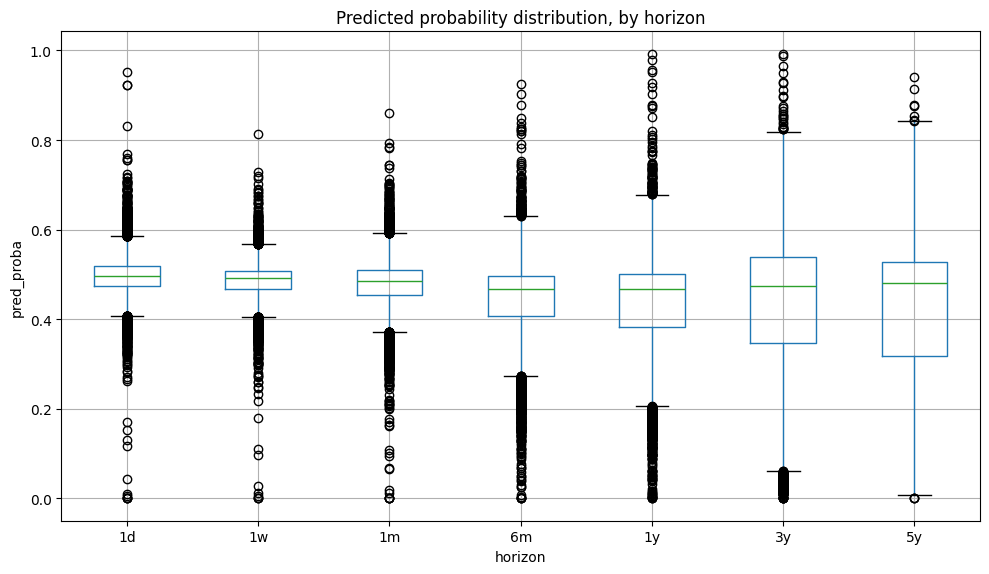

In [13]:
# Predicted probability distribution for all horizons
fig, ax = plt.subplots(figsize=(10, 6))
predictions.boxplot(column="pred_proba", by="horizon", ax=ax)
plt.title("Predicted probability distribution, by horizon")
plt.suptitle("")
plt.ylabel("pred_proba")
plt.tight_layout()
plt.show()

In [10]:
# Side by side comparison for one horizon
def compare_models_for_horizon(horizon):
    sub = focus[focus["horizon"] == horizon]
    pivot = sub.pivot_table(index="ticker", columns="model", values="pred_proba")
    pivot["n_models_present"] = pivot.notna().sum(axis=1)
    pivot["avg_pred_proba"] = pivot[MODELS].mean(axis=1)
    return pivot.sort_values(["n_models_present", "avg_pred_proba"], ascending=False)

compare_models_for_horizon("5y").head(20)

model,gradient_boosting,logistic_regression,mlpclassifier,random_forest,n_models_present,avg_pred_proba
ticker,,,,,,
JFIN,0.877120,0.502819,0.361232,0.670963,4,0.603033
GSL,0.768618,0.523395,0.390534,0.651376,4,0.583481
AMAL,0.758968,0.524853,0.386852,0.651287,4,0.580490
WAB,0.726918,0.527835,0.390320,0.649548,4,0.573655
IMO,0.741489,0.555265,0.344072,0.649034,4,0.572465
UBS,0.730540,0.531633,0.379722,0.639188,4,0.570271
BNED,0.852534,0.459106,0.364053,0.603836,4,0.569882
WGS,0.841417,0.516372,0.305245,0.611213,4,0.568562
MFC,0.723430,0.515343,0.382234,0.651662,4,0.568167


In [11]:
snapshot = pd.read_parquet(SNAPSHOT_FILE)

top10 = (
    focus.sort_values("pred_proba", ascending=False)
    .groupby(["horizon", "model"])
    .head(10)
    .reset_index(drop=True)
)

top10 = top10.merge(
    snapshot[["ticker"] + RETURN_COLS],
    on="ticker",
    how="left",
)

top10 = top10.sort_values(
    ["horizon", "model", "pred_proba"], ascending=[True, True, False]
).reset_index(drop=True)


def color_returns(val):
    if pd.isna(val):
        return ""
    color = "green" if val > 0 else "red" if val < 0 else "black"
    return f"color: {color}"


format_dict = {col: "{:.2%}" for col in RETURN_COLS}
format_dict["pred_proba"] = "{:.2%}"

for horizon in FOCUS_HORIZONS:
    for model in MODELS:
        subset = top10[(top10["horizon"] == horizon) & (top10["model"] == model)]
        if subset.empty:
            continue
        print(f"\n=== {horizon} — {model} ===")

        styled = (
            subset[["ticker", "pred_proba", "predicted_label"] + RETURN_COLS]
            .style
            .map(color_returns, subset=RETURN_COLS)
            .format(format_dict)
            .hide(axis="index")
        )
        display(styled)

/tmp/ipykernel_3889392/3793631705.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  focus.sort_values("pred_proba", ascending=False)



=== 6m — logistic_regression ===


ticker,pred_proba,predicted_label,ret_1d,ret_1w,ret_1m,ret_6m,ret_1y,ret_3y,ret_5y
CLS,92.39%,1,-6.00%,8.57%,-8.35%,10.48%,65.84%,1407.92%,3615.70%
LQDA,90.21%,1,-3.10%,-2.45%,6.04%,95.33%,350.03%,989.51%,3463.98%
STRL,87.78%,1,2.76%,-9.71%,-23.15%,57.36%,123.02%,894.78%,2660.27%
BELFB,82.53%,1,7.32%,-0.30%,-14.47%,29.31%,109.43%,411.79%,2053.71%
FIX,81.94%,1,1.88%,-0.23%,-7.26%,47.79%,146.49%,904.59%,2317.39%
POWL,81.28%,1,-0.30%,-10.13%,-21.21%,37.12%,164.76%,948.52%,2269.96%
BELFA,74.33%,1,6.39%,-4.30%,-20.76%,16.01%,95.09%,320.80%,1435.14%
VIST,73.18%,1,2.74%,1.37%,12.38%,16.27%,57.61%,169.92%,1370.77%
AEHR,71.49%,1,4.05%,4.80%,-5.27%,197.54%,373.25%,53.34%,1295.81%
CRS,70.40%,1,3.17%,-13.92%,-14.83%,67.50%,108.94%,785.68%,1356.88%



=== 6m — random_forest ===


ticker,pred_proba,predicted_label,ret_1d,ret_1w,ret_1m,ret_6m,ret_1y,ret_3y,ret_5y
ATAI,59.76%,1,0.00%,0.00%,47.13%,86.98%,75.12%,243.54%,-54.09%
CAR,59.49%,1,-9.58%,-13.82%,-6.47%,18.82%,-19.27%,-34.33%,68.32%
NEXT,58.85%,1,-0.15%,-4.07%,-11.23%,27.27%,-40.85%,20.65%,103.02%
BSVN,58.45%,1,0.56%,1.70%,0.32%,16.26%,16.36%,105.99%,188.51%
ET,58.36%,1,0.59%,0.00%,6.88%,13.87%,21.59%,94.30%,211.58%
USFD,58.28%,1,0.04%,3.52%,-1.29%,19.38%,20.71%,135.41%,199.64%
PFGC,58.17%,1,-0.31%,2.60%,1.64%,16.53%,13.93%,91.42%,157.75%
STVN,58.05%,1,-1.73%,0.86%,8.23%,24.51%,-19.38%,-35.85%,2.80%
HESM,57.99%,1,1.39%,0.47%,8.04%,18.15%,1.85%,65.61%,133.88%
UNM,57.96%,1,-0.76%,-0.13%,-5.23%,14.90%,22.81%,91.42%,268.17%


...

ticker,pred_proba,predicted_label,ret_1d,ret_1w,ret_1m,ret_6m,ret_1y,ret_3y,ret_5y
JFIN,67.10%,1,-2.26%,0.00%,-28.48%,-68.60%,-83.81%,-63.83%,-33.12%
CAPR,66.92%,1,-8.11%,-80.46%,-83.31%,-82.97%,-52.93%,-12.50%,-13.29%
SOHOO,65.96%,1,0.00%,0.00%,3.80%,-82.42%,-79.50%,-83.11%,-76.47%
MFC,65.17%,1,-0.25%,1.76%,9.14%,17.51%,46.32%,148.65%,187.67%
GSL,65.14%,1,-0.29%,1.67%,17.36%,21.78%,66.35%,157.24%,265.44%
AMAL,65.13%,1,-0.02%,-0.12%,4.97%,27.49%,73.50%,161.12%,254.46%
BPOP,65.01%,1,0.05%,2.03%,3.98%,32.91%,56.50%,162.22%,180.02%
WAB,64.95%,1,-0.55%,-3.85%,10.17%,25.33%,52.20%,149.39%,257.86%
IMO,64.90%,1,0.60%,0.85%,16.74%,23.84%,58.64%,158.97%,437.49%
IFS,64.89%,1,-0.34%,-2.38%,0.03%,22.47%,68.32%,167.15%,266.18%



=== 5y — gradient_boosting ===


ticker,pred_proba,predicted_label,ret_1d,ret_1w,ret_1m,ret_6m,ret_1y,ret_3y,ret_5y
JFIN,87.71%,1,-2.26%,0.00%,-28.48%,-68.60%,-83.81%,-63.83%,-33.12%
BNED,85.25%,1,0.16%,4.71%,-5.16%,38.94%,41.78%,-91.48%,-98.47%
BETR,84.51%,1,10.43%,7.75%,-22.16%,-25.47%,81.61%,-98.98%,-95.27%
WGS,84.14%,1,-5.58%,10.17%,-9.20%,-33.67%,-36.14%,778.68%,-82.59%
TYTMF,80.84%,1,0.00%,0.00%,0.00%,0.00%,40.39%,104.94%,76.28%
LSF,80.79%,1,-0.95%,-0.95%,-14.75%,33.76%,-40.14%,147.62%,-91.55%
GOGO,80.29%,1,1.09%,9.71%,20.46%,-7.93%,-73.64%,-72.26%,-59.38%
CVNA,78.66%,1,1.50%,3.14%,-8.12%,-27.05%,-20.09%,578.56%,-1.60%
ALDX,78.26%,1,-3.75%,1.32%,-36.63%,-71.05%,-69.14%,-81.02%,-82.93%
OKUR,77.74%,1,-4.50%,-7.28%,-14.35%,39.93%,72.85%,-95.24%,-95.54%



=== 5y — mlpclassifier ===


ticker,pred_proba,predicted_label,ret_1d,ret_1w,ret_1m,ret_6m,ret_1y,ret_3y,ret_5y
QTTB,52.80%,1,0.77%,3.50%,24.44%,290.05%,606.31%,-37.33%,-86.49%
RLAY,44.08%,0,-3.19%,2.11%,6.02%,144.23%,434.94%,49.44%,-42.97%
YDKG,43.96%,0,5.00%,2.94%,0.96%,-99.00%,-97.77%,-99.19%,-99.89%
UONEK,43.33%,0,3.07%,-0.79%,9.33%,-45.28%,-24.78%,-91.13%,-89.78%
VSA,41.89%,0,2.40%,-13.08%,-28.47%,-87.44%,-99.56%,-99.75%,-99.94%
SCYX,41.55%,0,29.76%,29.76%,14.42%,-18.35%,-12.32%,-79.49%,-91.19%
WCC,41.30%,0,0.24%,3.31%,7.10%,17.92%,67.15%,100.97%,236.55%
ZLAB,41.22%,0,0.33%,-4.94%,-4.60%,5.91%,-51.67%,-39.22%,-87.39%
EAF,41.10%,0,3.54%,-9.68%,11.26%,-59.00%,-51.65%,-87.27%,-93.95%
PASG,40.64%,0,-0.45%,-9.51%,-2.40%,-58.34%,-30.37%,-74.63%,-98.16%
